In [1]:
%load_ext autoreload
%autoreload 2

# Imports / インポート

This notebook imports reusable modules that handle each stage of the HAR pipeline.

このノートブックでは、HAR パイプラインの各処理を担当するモジュールを読み込みます。

### Modules Included / 読み込むモジュール
- Data loading / データ読み込み
- Configuration / 設定
- Preprocessing / 前処理
- Feature engineering / 特徴量生成
- Model evaluation / モデル評価
- Visualization / 可視化

In [34]:
# ==========================================================
# Import project modules / プロジェクトモジュールの読み込み
# ==========================================================

# Load utility functions for reading datasets and formatting notebook output
# データセットの読み込みとノートブック出力を整形するユーティリティ
from har_utils.data import (
    get_subject,
    print_clean_header
)

# Load global configuration values shared across the project
# プロジェクト全体で使用する設定値を読み込む
from har_utils.config import FILE_NAME_SUFFIX

# Load preprocessing functions for data cleaning and feature preparation
# データクリーニングと特徴量生成前処理を行う関数
from har_utils.preprocessing import (
    do_sanity_check,
    preprocessing_pipeline,
    preprocess_all_subjects
)

# Load machine learning model constructors
# 機械学習モデルを生成する関数
from har_utils.model import model_random_forest


# Load evaluation utilities for training and performance analysis
# モデルの学習および性能評価を行う関数
from har_utils.analysis import (
    preprocess_evaluate_loso_supervised,
    run_optuna_study,
    evaluate_loso,
    get_feature_importance,
    filter_features_by_importance
)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

## Load Dataset / データセットの読み込み

Load the pose estimation data for each subject into a dictionary, where the subject ID is used as the key. Display the shape of each dataset to verify that all files were loaded successfully.

各被験者の姿勢推定データを辞書に読み込み、被験者IDをキーとして管理します。あわせて各データセットのサイズを表示し、正しく読み込まれたことを確認します。

In [3]:
# Load all subject datasets into a dictionary for easy access
# 各被験者のデータセットを辞書に読み込み、一括管理する
all_subject = {}

for suffix in FILE_NAME_SUFFIX:

    # Read the current subject dataset from the CSV file
    # 現在の被験者データをCSVファイルから読み込む
    all_subject[suffix] = get_subject(suffix)

    # Display the dataset dimensions to verify successful loading
    # データが正しく読み込まれたか、データサイズを確認する
    print(f"Subject_{suffix} Shape: {all_subject[suffix].shape}")

Subject_1 Shape: (76456, 35)
Subject_2 Shape: (74638, 35)
Subject_3 Shape: (118087, 35)
Subject_5 Shape: (75981, 35)


## Data Sanity Check / データの健全性確認

Inspect each subject dataset before preprocessing to identify missing values, invalid entries, or other data quality issues.

前処理を行う前に、各被験者データを確認し、欠損値や異常値などのデータ品質の問題がないかを確認します。

In [4]:
# Perform a sanity check on each subject dataset before preprocessing
# 前処理を行う前に、各被験者データの整合性を確認する
for suffix in FILE_NAME_SUFFIX:

    # Check for missing values, invalid values, and dataset consistency
    # 欠損値・異常値・データの整合性を確認する
    do_sanity_check(all_subject[suffix], f"Subject_{suffix}")


____________________________________________________________

               Sanity Check - Subject_1
____________________________________________________________

NaN counts:
  Action Label: 3406

Inf counts:

____________________________________________________________

               Sanity Check - Subject_2
____________________________________________________________

NaN counts:
  Action Label: 3388

Inf counts:

____________________________________________________________

               Sanity Check - Subject_3
____________________________________________________________

NaN counts:
  Action Label: 11617

Inf counts:

____________________________________________________________

               Sanity Check - Subject_5
____________________________________________________________

NaN counts:
  Action Label: 4161

Inf counts:


## Data Preprocessing & Feature Engineering / データ前処理・特徴量生成

The preprocessing pipeline performs the following operations.

前処理パイプラインでは、以下の処理を実行します。

### Data Cleaning / データクリーニング
- Remove samples with missing activity labels.
- Normalize skeleton coordinates using the hip joint as the origin.
- Remove invalid frames with insufficient shoulder width.
- Standardize inconsistent activity labels.

- アクティビティラベルが欠損したサンプルを除去
- 股関節を基準として骨格座標を正規化
- 肩幅が閾値未満の無効フレームを除去
- 表記が異なるアクティビティラベルを統一

### Feature Engineering / 特徴量生成
- Compute joint angle features.
- Compute range-of-motion features.
- Compute velocity and acceleration features.

- 関節角度特徴量を計算
- 可動域（Range of Motion）特徴量を計算
- 速度および加速度特徴量を計算

### Temporal Aggregation / 時系列特徴量生成
- Combine all frame-level features into a single dataset.
- Generate multi-scale windowed features using 15-frame and 60-frame windows.

- フレーム単位の特徴量を統合
- 15フレームと60フレームのマルチスケール時間窓特徴量を生成

### Output / 出力
- Display summary statistics for Subject 1 as a representative example.
- 代表例として Subject 1 の前処理結果を表示

In [5]:
# Apply the preprocessing pipeline to every subject dataset
# 各被験者データに前処理パイプラインを適用する
all_subject_norm = {}

for suffix in FILE_NAME_SUFFIX:

    # Execute preprocessing to generate normalized, windowed feature data
    # 前処理を実行し、正規化およびウィンドウ化された特徴量を生成する
    all_subject_norm[suffix] = preprocessing_pipeline(all_subject[suffix])

    # Display summary statistics for one representative subject
    # 代表例として1名分の前処理結果を表示する
    if suffix == '1':
        print(f"Subject_{suffix} Shape: {all_subject_norm[suffix].shape}")
        print(f"Description of Subject_{suffix}:\n{all_subject_norm[suffix].describe().T.round(2)}")
        print(f"Number of features: {len(all_subject_norm[suffix].columns) - 1}")

Subject_1 Shape: (7073, 945)
Description of Subject_1:
                             count  mean   std   min   25%   50%   75%   max
short_nose_x_mean           7073.0 -0.00  0.40 -1.63 -0.41  0.08  0.28  1.47
short_nose_y_mean           7073.0 -1.28  0.23 -1.59 -1.41 -1.36 -1.28  1.63
short_left_eye_x_mean       7073.0  0.01  0.40 -1.60 -0.36  0.10  0.28  1.56
short_left_eye_y_mean       7073.0 -1.37  0.23 -1.67 -1.50 -1.46 -1.36  1.53
short_right_eye_x_mean      7073.0 -0.08  0.40 -1.73 -0.43 -0.05  0.23  1.46
...                            ...   ...   ...   ...   ...   ...   ...   ...
long_left_ankle_y_acc_max   7073.0  0.11  0.31  0.01  0.03  0.06  0.11  7.23
long_right_ankle_x_vel_max  7073.0  0.09  0.14  0.01  0.02  0.04  0.09  1.05
long_right_ankle_x_acc_max  7073.0  0.12  0.19  0.01  0.03  0.05  0.11  2.12
long_right_ankle_y_vel_max  7073.0  0.09  0.26  0.00  0.02  0.04  0.09  7.26
long_right_ankle_y_acc_max  7073.0  0.11  0.32  0.01  0.03  0.06  0.10  7.85

[944 rows x 8 column

## Grid Search for Window Size and Window Stride / ウィンドウサイズとウィンドウストライドのグリッドサーチ

This experiment jointly evaluates different **window size** and **window stride** combinations using Leave-One-Subject-Out (LOSO) cross-validation. Since these parameters are interdependent, they are optimized together rather than independently.

The following configurations are evaluated:

### Small Window Sizes
- **10**
- **15**
- **20**

### Large Window Sizes
- **60**
- **90**
- **120**

### Window Strides
- **1** – Maximum overlap
- **2** – Very high overlap
- **5** – High overlap
- **10** – Moderate overlap
- **15** – No overlap for the short window

A total of **45 configurations (3 × 3 × 5)** are evaluated. For each configuration, LOSO cross-validation is performed using a Random Forest classifier, and the mean Macro F1-score and standard deviation are recorded. The configuration with the highest mean Macro F1-score is selected for the subsequent experiments.

---

## ウィンドウサイズとウィンドウストライドのグリッドサーチ

本実験では、**ウィンドウサイズ**と**ウィンドウストライド**の組み合わせを Leave-One-Subject-Out（LOSO）交差検証によって同時に評価する。これらのパラメータは互いに影響するため、個別ではなく組み合わせとして最適化を行う。

評価する設定は以下のとおりである。

### 短いウィンドウサイズ
- **10**
- **15**
- **20**

### 長いウィンドウサイズ
- **60**
- **90**
- **120**

### ウィンドウストライド
- **1** – 最大の重なり
- **2** – 非常に大きな重なり
- **5** – 大きな重なり
- **10** – 中程度の重なり
- **15** – 短いウィンドウでは重なりなし

合計 **45通り（3 × 3 × 5）** の設定について Random Forest を用いた LOSO 交差検証を実施し、平均 Macro F1-score と標準偏差を比較する。最も高い平均 Macro F1-score を示した設定を以降の実験で使用する。

In [35]:
short_window_sizes = [10, 15, 20]
long_window_sizes = [60, 90, 120]
strides = [1, 2, 5, 10, 15]

results = []

total_experiments = (
    len(short_window_sizes)
    * len(long_window_sizes)
    * len(strides)
)

with tqdm(total=total_experiments, desc="Grid Search", unit="config") as pbar:

    for lws in long_window_sizes:
        for sws in short_window_sizes:
            for stride in strides:

                window_size = (sws, lws)

                pbar.set_postfix(
                    window=window_size,
                    stride=stride
                )

                model = model_random_forest()

                fold_results = preprocess_evaluate_loso_supervised(
                    all_subject=all_subject,
                    model=model,
                    window_size=window_size,
                    stride=stride
                )

                scores = [v["macro_f1"] for v in fold_results.values()]
                mean = np.mean(scores)
                std = np.std(scores)

                results.append({
                    "Window Size": window_size,
                    "Stride": stride,
                    "Mean Macro F1": mean,
                    "Std": std
                })

                pbar.update(1)

summary_df = (
    pd.DataFrame(results)
      .sort_values(
          by=["Mean Macro F1", "Std"],
          ascending=[False, True]
      )
      .reset_index(drop=True)
)

summary_df

Grid Search:   0%|          | 0/45 [00:00<?, ?config/s]

Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier


KeyboardInterrupt: 

## Model Training & Evaluation / モデル学習・評価

Train a Random Forest classifier and evaluate its performance using Leave-One-Subject-Out (LOSO) cross-validation.

Random Forest 分類器を学習し、Leave-One-Subject-Out（LOSO）交差検証を用いて性能を評価します。

### Evaluation Setup / 評価設定
- Window sizes: 15 and 60 frames
- Classifier: Random Forest
- Evaluation method: Leave-One-Subject-Out (LOSO)
- Performance metric: Macro F1-score
       
- 時間窓サイズ：15フレーム・60フレーム
- 分類器：Random Forest
- 評価手法：Leave-One-Subject-Out（LOSO）
- 評価指標：Macro F1-score

### Window Size: 15, 60 | Stride: 10 / ウィンドウサイズ: 15, 60｜ストライド: 10

This section evaluates the machine learning models using multi-scale temporal windows of **15** and **60** frames with a **stride of 10**.

このセクションでは、**15フレーム**および**60フレーム**のマルチスケール時間窓と、**ストライド10**を用いて機械学習モデルを学習・評価します。

In [6]:
# Display the current temporal window size used for feature extraction
# 特徴量生成に使用する時間窓サイズを表示する
print_clean_header("Window Size: (15, 60)")

# Create a Random Forest classifier with the predefined configuration
# 設定済みのRandom Forest分類器を作成する
model = model_random_forest()

# Evaluate the model using Leave-One-Subject-Out (LOSO) cross-validation
# Leave-One-Subject-Out（LOSO）交差検証でモデルを評価する
result = evaluate_loso(all_subject_norm, model)


                             Window Size: (15, 60)                              
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 1  |  Train: ['2', '3', '5'] 
----------------------------------------------------
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.63      0.12      0.20
  Biting                      0.00      0.00      0.00
  Eating snacks               0.28      0.72      0.40
  Head banging                0.96      0.30      0.46
  Sitting quietly             0.36      0.18      0.24
  Throwing things             0.41      0.79      0.54
  Using phone                 0.00      0.00      0.00
  Walking                     0.86      0.99      0.92

  Macro F1: 0.346
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 2  |  Train: ['1', '

### Window Size: 15, 90 | Stride: 10 / ウィンドウサイズ: 15, 90｜ストライド: 10

This section evaluates the machine learning models using multi-scale temporal windows of **15** and **90** frames with a **stride of 10**.

このセクションでは、**15フレーム**および**90フレーム**のマルチスケール時間窓と、**ストライド10**を用いて機械学習モデルを学習・評価します。

In [7]:
print_clean_header("Window Size of (15, 90)")
# Create a Random Forest classifier with the predefined configuration
# 設定済みのRandom Forest分類器を作成する
model = model_random_forest()
result = preprocess_evaluate_supervised(all_subject, model=model, window_size=(15, 90))


                            Window Size of (15, 90)                             
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 1  |  Train: ['2', '3', '5'] 
----------------------------------------------------
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.77      0.12      0.21
  Biting                      0.00      0.00      0.00
  Eating snacks               0.36      0.87      0.51
  Head banging                0.25      0.70      0.37
  Sitting quietly             0.00      0.00      0.00
  Throwing things             0.52      0.83      0.64
  Using phone                 0.00      0.00      0.00
  Walking                     0.85      1.00      0.92

  Macro F1: 0.332
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 2  |  Train: ['1', '

### Window Size: 15, 120 | Stride: 10 / ウィンドウサイズ: 15, 120｜ストライド: 10

This section evaluates the machine learning models using multi-scale temporal windows of **15** and **120** frames with a **stride of 10**.

このセクションでは、**15フレーム**および**120フレーム**のマルチスケール時間窓と、**ストライド10**を用いて機械学習モデルを学習・評価します。

In [ ]:
print_clean_header("Window Size of (15, 120)")
# Create a Random Forest classifier with the predefined configuration
# 設定済みのRandom Forest分類器を作成する
model = model_random_forest()
result = preprocess_evaluate_loso_supervised(all_subject, model=model, window_size=(15, 120))


                            Window Size of (15, 120)                            
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 1  |  Train: ['2', '3', '5'] 
----------------------------------------------------
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.67      0.12      0.20
  Biting                      0.00      0.00      0.00
  Eating snacks               0.36      0.88      0.51
  Head banging                0.25      0.67      0.37
  Sitting quietly             0.00      0.00      0.00
  Throwing things             0.55      0.85      0.67
  Using phone                 0.00      0.00      0.00
  Walking                     0.85      1.00      0.92

  Macro F1: 0.332
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 2  |  Train: ['1', '

## Feature Importance Analysis / 特徴量重要度の分析

Calculate and rank the most important features using a Random Forest model.

Random Forest を用いて特徴量の重要度を算出し、重要な特徴量を順位付けします。


════════════════════════════════════════════════════
  TOP 20 FEATURE IMPORTANCES
════════════════════════════════════════════════════
  Rank   Feature                                  Importance
  ────── ──────────────────────────────────────── ──────────
  1      long_min_wrist_to_nose_dist_min              0.0157
  2      long_left_knee_x_min                         0.0142
  3      long_min_wrist_height_rel_shoulder_min       0.0098
  4      short_min_wrist_to_nose_dist_max             0.0092
  5      short_left_knee_y_min                        0.0090
  6      long_left_knee_y_mean                        0.0088
  7      long_right_wrist_to_nose_dist_min            0.0084
  8      long_min_wrist_height_rel_shoulder_mean      0.0083
  9      long_left_ankle_x_std                        0.0080
  10     long_left_knee_x_mean                        0.0077
  11     long_right_ankle_y_std                       0.0076
  12     long_left_knee_y_min                         0.0075
  13     l

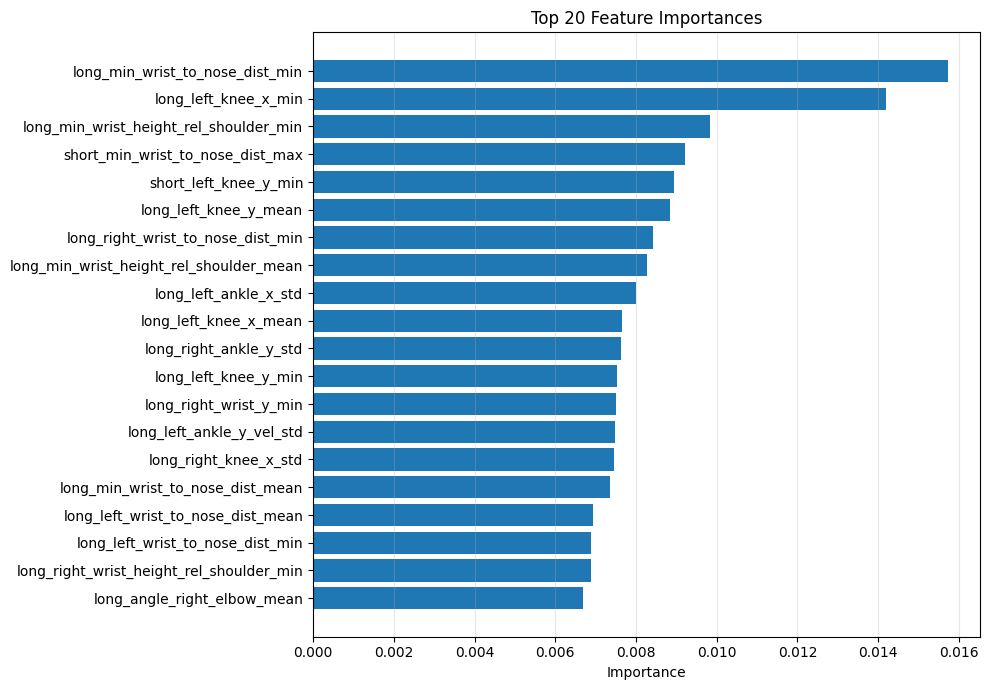

In [11]:
importance_df = get_feature_importance(all_subject_norm, top_n=20)

## Feature Importance-Based Feature Selection / 特徴量重要度に基づく特徴量選択

The effect of feature selection is evaluated by retaining the **top 50, 100, 150, and 200** most important features ranked by the Random Forest feature importance scores. A Random Forest classifier is then trained and evaluated on each feature subset to examine how the number of selected features influences classification performance.

Random Forest による特徴量重要度を用いて、**上位50、100、150、200個**の特徴量を選択し、それぞれの特徴量セットでモデルを学習・評価します。これにより、使用する特徴量数が分類性能に与える影響を確認します。

In [ ]:
# ==========================================
# Window Size: (15, 20) | Stride: 5
# ==========================================

# Try four different cutoffs for feature importance filtering and evaluate the model performance with each subset of features
# 特徴量重要度のフィルタリングに対して3つの異なるカットオフを試し、各特徴量サブセットでモデルの性能を評価する
for top_n in [50, 100, 150, 200]:
    print_clean_header(f"\nTesting Top {top_n} Features")
    
    filtered_subjects = filter_features_by_importance(
        all_subject_norm,
        importance_df,
        top_n=top_n
    )
    rf = model_random_forest()
    results = evaluate_loso(filtered_subjects, rf);


                            
Testing Top 50 Features                            
Features kept: 50
Features dropped: 894
Subjects processed: ['1', '2', '3', '5']
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 1  |  Train: ['2', '3', '5'] 
----------------------------------------------------
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.61      0.30      0.40
  Biting                      0.00      0.00      0.00
  Eating snacks               0.39      1.00      0.56
  Head banging                0.97      0.28      0.44
  Sitting quietly             0.16      0.07      0.10
  Throwing things             0.54      0.64      0.58
  Using phone                 1.00      0.12      0.21
  Walking                     0.77      0.99      0.87

  Macro F1: 0.396
Model being evaluated: RandomForestClassifier

---------------

## LOSO Evaluation with Different Window Strides / 異なるウィンドウストライドによるLOSO評価

This section evaluates the effect of different window stride values on Human Activity Recognition performance using Leave-One-Subject-Out (LOSO) cross-validation. The objective is to examine how the amount of overlap between consecutive windows influences classification performance, computational cost, and model generalization.

Since the smallest temporal window is **15 frames**, the stride is limited to **15 frames or less** to ensure complete temporal coverage without skipping observations. The following stride values are evaluated:

- **1** – Maximum overlap
- **2** – Very high overlap
- **5** – High overlap
- **10** – Moderate overlap
- **15** – No overlap for the short window

このセクションでは、異なるウィンドウストライドを用いて Leave-One-Subject-Out（LOSO）交差検証を実施し、Human Activity Recognition の性能を評価します。連続するウィンドウ間の重なり具合が、分類性能、計算コスト、およびモデルの汎化性能に与える影響を検証します。

最小の時間ウィンドウは **15フレーム**であるため、データの取りこぼしを防ぐためにストライドは **15フレーム以下**とします。評価するストライドは以下のとおりです。

- **1** – 最大の重なり
- **2** – 非常に大きな重なり
- **5** – 大きな重なり
- **10** – 中程度の重なり
- **15** – 短いウィンドウでは重なりなし

In [25]:
window_strides = [1, 2, 5, 10, 15]
window_size = (15, 120)
for stride in window_strides:
    print_clean_header(f'Window Stride: {stride}', border_char='#')
    model = model_random_forest()
    preprocess_evaluate_loso_supervised(all_subject=all_subject, 
                                        model=model, 
                                        window_size=window_size, 
                                        stride=stride);


################################################################################
                                Window Stride: 1                                
################################################################################
Model being evaluated: RandomForestClassifier

----------------------------------------------------
 
Fold — Test Subject: 1  |  Train: ['2', '3', '5'] 
----------------------------------------------------
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.64      0.07      0.13
  Biting                      0.00      0.00      0.00
  Eating snacks               0.40      0.80      0.53
  Head banging                0.17      0.71      0.27
  Sitting quietly             0.00      0.00      0.00
  Throwing things             0.51      0.90      0.65
  Using phone                 0.00      0.00      0.00
  Walking                     0.89      1.00      0.94


### Conclusion / 結論

- **Stride = 5** achieved the best overall performance with the **highest mean Macro F1-score (0.497)** and the **lowest standard deviation (0.101)** among all evaluated stride values.
- Very small strides (1 and 2) generated many highly overlapping windows but did not improve performance, likely due to redundant training samples.
- Larger strides (10 and 15) reduced the number of training windows, resulting in a slight decrease in overall performance.
- Based on these results, a **window stride of 5** provides the best balance between classification performance, model stability, and computational efficiency, and is therefore used in the subsequent experiments.

---

### 結論

- **Stride = 5** は、評価したストライドの中で **最も高い平均 Macro F1-score（0.497）** と **最も小さい標準偏差（0.101）** を示し、最も良い結果となった。
- Stride が **1** や **2** の場合は重複するウィンドウが多く生成されるが、学習データの冗長性が高くなるため、性能の向上にはつながらなかった。
- Stride が **10** や **15** では生成されるウィンドウ数が減少し、分類性能がわずかに低下した。
- 以上の結果から、**Stride = 5** が分類性能、モデルの安定性、および計算効率のバランスが最も優れているため、以降の実験ではこの設定を採用する。

## Feature Importance Analysis with the Optimized Preprocessing Configuration / 最適化した前処理設定による特徴量重要度の分析

After selecting the optimal window configuration (**window sizes: 15 and 120**, **stride: 5**), the feature importance is recomputed using the updated dataset. Since changing the window stride alters the generated samples and feature distributions, the feature importance ranking may also change.

The updated feature ranking is used to select the most informative features for all subsequent experiments.

最適なウィンドウ設定（**ウィンドウサイズ: 15・120、ストライド: 5**）を決定した後、この設定で生成したデータセットを用いて特徴量重要度を再計算する。ウィンドウストライドを変更すると生成されるサンプルや特徴量の分布が変化するため、特徴量重要度の順位も変化する可能性がある。

更新された特徴量重要度に基づいて重要な特徴量を選択し、以降のすべての実験で使用する。

In [32]:
all_subject_norm_stride_5 = preprocess_all_subjects(all_subject, window_size=(15, 120), stride=5)
# Try four different cutoffs for feature importance filtering and evaluate the model performance with each subset of features
# 特徴量重要度のフィルタリングに対して3つの異なるカットオフを試し、各特徴量サブセットでモデルの性能を評価する
for top_n in [50, 100, 150, 200]:
    print_clean_header(f"\nTesting Top {top_n} Features")
    
    filtered_subjects = filter_features_by_importance(
        all_subject_norm_stride_5,
        importance_df,
        top_n=top_n
    )
    rf = model_random_forest()
    results = evaluate_loso(filtered_subjects, rf);


                            
Testing Top 50 Features                            
Features kept: 50
Features dropped: 894
Subjects processed: ['1', '2', '3', '5']
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier

                LOSO RESULTS SUMMARY                
  Subject        Macro F1
  ──────────── ──────────
  1                 0.547
  2                 0.619
  3                 0.447
  5                 0.718
  ──────────── ──────────
  Mean              0.583
  Std               0.099
════════════════════════════════════════════════════


                           
Testing Top 100 Features                            
Features kept: 100
Features dropped: 844
Subjects processed: ['1', '2', '3', '5']
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model bei

## Model Evaluation with Optimized Configuration / 最適化した設定によるモデル評価

Based on the previous experiments, the following configuration achieved the best overall balance between classification performance, model stability, and computational efficiency:

- **Window Sizes:** 15 and 120 frames
- **Window Stride:** 5
- **Selected Features:** Top 100 features based on Random Forest feature importance

Using this optimized preprocessing configuration, the following experiments evaluate and compare the performance of different machine learning models using Leave-One-Subject-Out (LOSO) cross-validation.

これまでの実験結果に基づき、以下の設定が分類性能、モデルの安定性、および計算効率のバランスにおいて最も優れていると判断した。

- **ウィンドウサイズ:** 15フレーム、120フレーム
- **ウィンドウストライド:** 5
- **使用特徴量:** Random Forest の特徴量重要度による上位100特徴量

以降の実験では、この最適化した前処理設定を用いて、Leave-One-Subject-Out（LOSO）交差検証により各機械学習モデルの性能を評価・比較する。

In [31]:
print_clean_header("Window Size of (15, 120) | Stride: 5")
# Create a Random Forest classifier with the predefined configuration
# 設定済みのRandom Forest分類器を作成する
model = model_random_forest()
result = preprocess_evaluate_loso_supervised(all_subject, model=model, window_size=(15, 120), stride=5)


                      Window Size of (15, 120) | Stride: 5                      
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier

                LOSO RESULTS SUMMARY                
  Subject        Macro F1
  ──────────── ──────────
  1                 0.466
  2                 0.597
  3                 0.344
  5                 0.579
  ──────────── ──────────
  Mean              0.497
  Std               0.101
════════════════════════════════════════════════════



## Effect of Removing Low-Quality Frames / 低品質フレーム除外の影響評価

This experiment compares model performance with and without removing frames that have abnormally small shoulder widths. The objective is to determine whether filtering these potentially unreliable pose estimations improves classification performance or whether the additional preprocessing step has little impact.

この実験では、肩幅が異常に小さいフレームを**除外した場合**と**除外しない場合**でモデル性能を比較します。目的は、このような信頼性の低い姿勢推定結果を除外することが分類性能の向上につながるか、あるいは前処理としての効果が限定的であるかを評価することです.

# Optuna

In [16]:
# Run on your best configuration — top 100 features
filtered_100 = filter_features_by_importance(
    all_subject_norm, importance_df, top_n=100
)

study = run_optuna_study(filtered_100, n_trials=50)

Features kept: 100
Features dropped: 844
Subjects processed: ['1', '2', '3', '5']

               
OPTUNA SEARCH  —  50 trials  |  4 LOSO folds each               


Tuning:  16%|█▌        | 8/50 [04:52<24:37, 35.19s/trial][W 2026-06-14 01:02:57,203] Trial 8 failed with parameters: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 11, 'max_features': 'sqrt'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/har_utils/analysis.py", line 403, in <lambda>
  File "/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/har_utils/analysis.py", line 7, in optuna_objective_loso
    from har_utils.preprocessing import preprocess_all_subjects
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_m

KeyboardInterrupt: 

In [ ]:
best_model = model_random_forest(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

results = evaluate_loso(filtered_100, model_param=best_model, model_type=None);


────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.44      0.25      0.32
  Biting                      0.00      0.00      0.00
  Eating snacks               0.57      1.00      0.72
  Head banging                0.98      0.67      0.79
  Sitting quietly             0.87      0.97      0.92
  Throwing things             0.49      0.53      0.51
  Using phone                 1.00      0.32      0.49
  Walking                     0.83      0.99      0.91

  Macro F1: 0.582

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  A

# Experiment Results Summary

## Evaluation Methodology
- **Dataset**: 4 subjects performing 8 activities (4 normal, 4 abnormal)
- **Evaluation**: Leave-One-Subject-Out Cross-Validation (LOSO)
- **Metric**: Macro F1 Score (unweighted average across all 8 classes)
- **Activities**: Attacking, Biting, Eating snacks, Head banging, Sitting quietly, Throwing things, Using phone, Walking

---

## Overall LOSO Performance Across Experiments

| # | Configuration | Model | Mean F1 | Std | Notes |
|---|---|---|---|---|---|
| 1 | Frame-level coordinates only | Random Forest (default) | 0.397 | 0.122 | Baseline after y-normalization fix |
| 2 | + Angle features | Random Forest (default) | 0.530 | — | Single test subject only |
| 3 | + Range of motion features | Random Forest (default) | 0.530 | — | Single test subject only |
| 4 | Windowed features (size=30, stride=10) | Random Forest (default) | 0.397 | 0.122 | First LOSO benchmark |
| 5 | Multi-scale windows (15, 60) + acceleration | Random Forest (default) | 0.472 | 0.115 | Multi-scale introduced |
| 6 | Multi-scale windows (15, 90) + acceleration | Random Forest (default) | 0.472 | 0.115 | No improvement over (15,60) |
| 7 | Multi-scale windows (15, 120) + acceleration | Random Forest (default) | 0.486 | 0.140 | Best window configuration |
| 8 | Top 100 features (15, 120) | Random Forest (default) | 0.508 | 0.106 | Best mean + lowest std |
| 9 | Top 150 features (15, 120) | Random Forest (default) | 0.488 | 0.117 | Diminishing returns |
| 10 | Top 200 features (15, 120) | Random Forest (default) | 0.474 | 0.122 | Worse than top 100 |
| 11 | Top 100 features (15, 120) | HistGradientBoosting | 0.496 | 0.117 | Underperforms RF |
| 12 | Top 150 features (15, 120) | HistGradientBoosting | 0.473 | 0.142 | High variance |
| 13 | Top 200 features (15, 120) | HistGradientBoosting | 0.460 | 0.146 | Worst HGB result |
| **14** | **Top 100 features (15, 120), Optuna-tuned** | **Random Forest** | **0.554** | **0.117** | **Best overall result** |

---

## Best Configuration — Per-Subject Breakdown

**Random Forest | Top 100 Features | Window (15, 120) | Optuna-tuned**

`n_estimators=400, max_depth=10, min_samples_leaf=21, min_samples_split=4, max_features=log2`

| Subject | Macro F1 | Notes |
|---|---|---|
| Subject 1 | 0.582 | Strong improvement from tuning |
| Subject 2 | 0.655 | Best performing fold |
| Subject 3 | 0.357 | Consistently hardest subject |
| Subject 5 | 0.622 | Good generalisation |
| **Mean** | **0.554** | |
| **Std** | **0.117** | |

---

## Best Configuration — Per-Class F1 (Averaged Across Folds)

| Class | Type | Avg F1 | Notes |
|---|---|---|---|
| Walking | Normal | ~0.95 | Consistently well recognised |
| Head banging | Abnormal | ~0.76 | Strong, benefits from motion signal |
| Attacking | Abnormal | ~0.51 | Variable across subjects |
| Throwing things | Abnormal | ~0.68 | Reliable across folds |
| Sitting quietly | Normal | ~0.65 | Improved significantly with tuning |
| Eating snacks | Normal | ~0.52 | Dominant class, absorbs confusions |
| Using phone | Normal | ~0.12 | Fundamentally hard to distinguish |
| Biting | Abnormal | ~0.16 | Feature space overlap with Eating snacks |

---

## Key Findings

| Finding | Detail |
|---|---|
| **Normalization bug** | y-coordinates were being centered using hip_center_x instead of hip_center_y. Fixing this was the single most impactful change. |
| **Torso height scaling** | Replacing shoulder-width normalization with torso height improved cross-subject consistency of wrist height features. |
| **Multi-scale windowing** | Combining a 15-frame short window with a 120-frame long window outperformed any single window size. |
| **Feature engineering** | Wrist-to-nose distance and wrist height relative to shoulder were the top two features by importance. |
| **Feature selection** | 100 features outperformed 944. The importance distribution was flat — most features were noise. |
| **Hyperparameter tuning** | min_samples_leaf=21 (vs default 1) was the key generalisation improvement found by Optuna. |
| **Subject variability** | Subject 3 scores ~0.36 across all configurations — a structural data challenge, not a model limitation. |
| **Fundamental ceiling** | Biting and Using phone overlap with Eating snacks in feature space. Confirmed by distribution plots and consistent with the published paper on this dataset. |

---

## Improvement Trajectory

| Stage | Mean LOSO F1 | Gain |
|---|---|---|
| Initial baseline | 0.397 | — |
| Multi-scale windowing | 0.486 | +0.089 |
| Feature selection (top 100) | 0.508 | +0.022 |
| Optuna hyperparameter tuning | 0.554 | +0.046 |
| **Total improvement** | | **+0.157 (+39.5%)** |